In [1]:
import torch
import torch.nn as nn
import torchvision.models as models

In [2]:
from google.colab import drive
import zipfile
import os

zip_path = '/content/DL_Assignment1_Dataset.zip'

if os.path.exists(zip_path):
    print("Zip file found")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall('dataset')
        print("Dataset unzipped successfully!")
else:
    print("Zip file not found at the specified path.")
    print("Let's search for it in your Drive...")


Zip file found
Dataset unzipped successfully!


In [3]:
import os
import glob
import numpy as np

# Paths
img_dir = "/content/dataset/Dataset/Dataset/images"
ann_dir = "/content/dataset/Dataset/Dataset/annotations"

# Collect IDs
img_ids = [os.path.splitext(os.path.basename(f))[0] for f in glob.glob(os.path.join(img_dir, "*.jpg"))]
ann_ids = [os.path.basename(f).split("_")[0] for f in glob.glob(os.path.join(ann_dir, "*.npy"))]

# Unique sets
img_ids = set(img_ids)
ann_ids = set(ann_ids)

# Intersection = valid samples
valid_ids = sorted(img_ids & ann_ids)
print(f"Found {len(valid_ids)} matched samples")


Found 3999 matched samples


In [4]:
import os
import glob
import torch
from torch.utils.data import Dataset
from PIL import Image
import numpy as np

class AffectDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None, use_landmarks=False):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        self.use_landmarks = use_landmarks

        # Collect image and annotation IDs
        img_ids = [os.path.splitext(os.path.basename(f))[0]
                   for f in glob.glob(os.path.join(img_dir, "*.jpg"))]
        ann_ids = [os.path.basename(f).split("_")[0]
                   for f in glob.glob(os.path.join(ann_dir, "*.npy"))]

        # Keep only common IDs
        self.valid_ids = sorted(set(img_ids) & set(ann_ids))
        print(f"Found {len(self.valid_ids)} matched samples")

    def __len__(self):
        return len(self.valid_ids)

    def __getitem__(self, idx):
        sample_id = self.valid_ids[idx]

        # Load image
        img_path = os.path.join(self.img_dir, sample_id + ".jpg")
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)

        # Load annotations
        exp = np.load(os.path.join(self.ann_dir, f"{sample_id}_exp.npy"), allow_pickle=True)
        val = np.load(os.path.join(self.ann_dir, f"{sample_id}_val.npy"), allow_pickle=True)
        aro = np.load(os.path.join(self.ann_dir, f"{sample_id}_aro.npy"), allow_pickle=True)

        exp = int(np.array(exp).squeeze())
        val = float(np.array(val).squeeze())
        aro = float(np.array(aro).squeeze())

        exp = torch.tensor(exp, dtype=torch.long)
        val = torch.tensor(val, dtype=torch.float32)
        aro = torch.tensor(aro, dtype=torch.float32)

        return image, exp, val, aro


In [5]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# Dataset
dataset = AffectDataset(
    img_dir="/content/dataset/Dataset/Dataset/images",
    ann_dir="/content/dataset/Dataset/Dataset/annotations",
    transform=transform,
    use_landmarks=False   # set True if you want landmarks too
)

# DataLoader
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Test one batch
images, exp, val, aro = next(iter(loader))
print(images.shape)   # [32, 3, 224, 224]
print(exp.shape)      # [32]
print(val.shape)      # [32]
print(aro.shape)      # [32]


Found 3999 matched samples
torch.Size([32, 3, 224, 224])
torch.Size([32])
torch.Size([32])
torch.Size([32])


In [ ]:
from torch.utils.data import random_split, DataLoader

# Split into train/val/test
total = len(dataset)
train_size = int(0.7 * total)
val_size   = int(0.15 * total)
test_size  = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(dataset, [train_size, val_size, test_size])

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False)

In [ ]:
class MultiTaskCNN(nn.Module):
    def __init__(self, backbone="resnet18", num_classes=8):
        super(MultiTaskCNN, self).__init__()

        if backbone == "resnet18":
            base = models.resnet18(pretrained=True)
            in_features = base.fc.in_features
            base.fc = nn.Identity()
            self.backbone = base

        elif backbone == "efficientnet_b0":
            base = models.efficientnet_b0(pretrained=True)
            in_features = base.classifier[1].in_features
            base.classifier = nn.Identity()
            self.backbone = base

        elif backbone == "vgg16":
            base = models.vgg16(pretrained=True)
            in_features = 25088   # fixed size after flatten
            base.classifier = nn.Identity()
            self.backbone = base


        elif backbone == "mobilenet_v2":
            base = models.mobilenet_v2(pretrained=True)
            in_features = base.classifier[1].in_features
            base.classifier = nn.Identity()
            self.backbone = base

        else:
            raise ValueError("Backbone not supported. Use 'resnet18' or 'efficientnet_b0'.")

        # Heads
        self.classifier_head = nn.Linear(in_features, num_classes)
        self.regression_head = nn.Linear(in_features, 2)

    def forward(self, x):
        feats = self.backbone(x)
        exp_out = self.classifier_head(feats)
        va_out = self.regression_head(feats)
        return exp_out, va_out

In [ ]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskCNN("resnet18").to(device)

# Loss functions
ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 210MB/s]


In [ ]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss, total_cls, total_reg = 0, 0, 0

    for images, exp, val, aro in loader:
        images, exp, val, aro = images.to(device), exp.to(device), val.to(device), aro.to(device)
        va_targets = torch.stack([val, aro], dim=1)  # [B,2]

        # Forward pass
        exp_logits, va_preds = model(images)

        # Losses
        loss_cls = ce_loss(exp_logits, exp)
        loss_reg = mse_loss(va_preds, va_targets)
        loss = loss_cls + 0.5 * loss_reg  # weighted sum

        # Backprop
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_cls += loss_cls.item()
        total_reg += loss_reg.item()

    return total_loss / len(loader), total_cls / len(loader), total_reg / len(loader)

In [ ]:
def evaluate(model, loader):
    model.eval()
    total_loss, correct, n = 0, 0, 0
    with torch.no_grad():
        for images, exp, val, aro in loader:
            images, exp, val, aro = images.to(device), exp.to(device), val.to(device), aro.to(device)
            va_targets = torch.stack([val, aro], dim=1)

            exp_logits, va_preds = model(images)

            # Compute losses
            loss_cls = ce_loss(exp_logits, exp)
            loss_reg = mse_loss(va_preds, va_targets)
            loss = loss_cls + 0.5 * loss_reg

            total_loss += loss.item()
            _, preds = exp_logits.max(1)
            correct += (preds == exp).sum().item()
            n += exp.size(0)

    acc = correct / n
    return total_loss / len(loader), acc

In [ ]:
num_epochs = 10

for epoch in range(num_epochs):
    train_loss, train_cls, train_reg = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} (Cls: {train_cls:.4f}, Reg: {train_reg:.4f})")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/10
  Train Loss: 1.9215 (Cls: 1.8157, Reg: 0.2116)
  Val Loss:   1.6870, Val Acc: 0.3890
Epoch 2/10
  Train Loss: 1.0440 (Cls: 0.9884, Reg: 0.1113)
  Val Loss:   1.7240, Val Acc: 0.4040
Epoch 3/10
  Train Loss: 0.3878 (Cls: 0.3548, Reg: 0.0660)
  Val Loss:   1.7107, Val Acc: 0.4207
Epoch 4/10
  Train Loss: 0.1169 (Cls: 0.0953, Reg: 0.0430)
  Val Loss:   1.8341, Val Acc: 0.4157
Epoch 5/10
  Train Loss: 0.0461 (Cls: 0.0321, Reg: 0.0278)
  Val Loss:   1.8418, Val Acc: 0.4424
Epoch 6/10
  Train Loss: 0.0321 (Cls: 0.0201, Reg: 0.0240)
  Val Loss:   1.8716, Val Acc: 0.4424
Epoch 7/10
  Train Loss: 0.0231 (Cls: 0.0148, Reg: 0.0166)
  Val Loss:   1.9190, Val Acc: 0.4407
Epoch 8/10
  Train Loss: 0.0221 (Cls: 0.0133, Reg: 0.0176)
  Val Loss:   1.9321, Val Acc: 0.4474
Epoch 9/10
  Train Loss: 0.0178 (Cls: 0.0104, Reg: 0.0148)
  Val Loss:   1.9593, Val Acc: 0.4391
Epoch 10/10
  Train Loss: 0.0174 (Cls: 0.0101, Reg: 0.0147)
  Val Loss:   1.9761, Val Acc: 0.4307


In [ ]:
def evaluate_with_preds_and_images(model, loader):
    model.eval()
    all_preds, all_labels, all_images = [], [], []

    with torch.no_grad():
        for images, exp, val, aro in loader:
            images, exp = images.to(device), exp.to(device)
            exp_logits, va_preds = model(images)
            _, preds = exp_logits.max(1)

            # Store results
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(exp.cpu().numpy())
            all_images.extend(images.cpu())  # keep images

    return all_preds, all_labels, all_images

# Run on test set
preds, labels, all_images = evaluate_with_preds_and_images(model, test_loader)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

print("Test Accuracy:", accuracy_score(labels, preds))
print("F1-score:", f1_score(labels, preds, average='weighted'))
print(classification_report(labels, preds))

Test Accuracy: 0.4176372712146423
F1-score: 0.41947620014463494
              precision    recall  f1-score   support

           0       0.38      0.39      0.38        85
           1       0.71      0.66      0.68        80
           2       0.33      0.34      0.34        83
           3       0.42      0.41      0.41        64
           4       0.47      0.50      0.48        62
           5       0.47      0.43      0.45        79
           6       0.27      0.29      0.28        70
           7       0.33      0.33      0.33        78

    accuracy                           0.42       601
   macro avg       0.42      0.42      0.42       601
weighted avg       0.42      0.42      0.42       601



In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_val = np.sqrt(mean_squared_error(vals, [v[0] for v in va_preds]))
rmse_aro = np.sqrt(mean_squared_error(aros, [v[1] for v in va_preds]))
print("Valence RMSE:", rmse_val)
print("Arousal RMSE:", rmse_aro)


Valence RMSE: 0.4025845309110668
Arousal RMSE: 0.3763620403885042


In [ ]:
!pip install pingouin

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.4/204.4 kB 8.2 MB/s eta 0:00:00


In [ ]:
import pingouin as pg

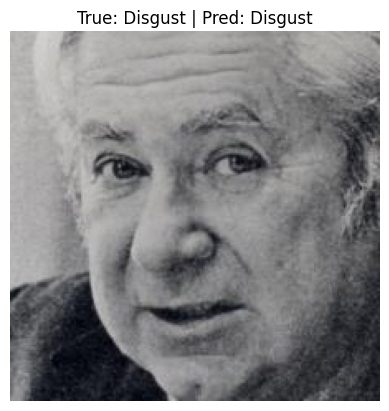

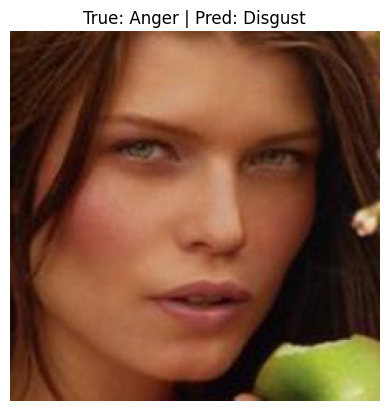

In [ ]:
import matplotlib.pyplot as plt
import random

class_names = ["Neutral", "Happy", "Sad", "Surprise", "Fear", "Disgust", "Anger", "Contempt"]

def show_example(images, labels, preds, correct=True):
    idxs = [i for i in range(len(labels)) if (labels[i] == preds[i]) == correct]
    if not idxs:
        print("No examples found for this case!")
        return

    idx = random.choice(idxs)
    img, true_label, pred_label = images[idx], labels[idx], preds[idx]

    img = img.permute(1, 2, 0).numpy()  # convert tensor to numpy
    plt.imshow(img)
    plt.title(f"True: {class_names[true_label]} | Pred: {class_names[pred_label]}")
    plt.axis("off")
    plt.show()

#correct prediction
show_example(all_images, labels, preds, correct=True)

#incorrect prediction
show_example(all_images, labels, preds, correct=False)


In [ ]:
torch.save(model.state_dict(), "multitask_resnet18.pth")

**efficientnet_b0**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultiTaskCNN("efficientnet_b0").to(device)

# Losses + Optimizer
ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)




/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 163MB/s]


In [ ]:
# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_cls, train_reg = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} (Cls: {train_cls:.4f}, Reg: {train_reg:.4f})")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc: {val_acc:.4f}")

Epoch 1/10
  Train Loss: 2.1021 (Cls: 2.0022, Reg: 0.1998)
  Val Loss:   1.9353, Val Acc: 0.3005
Epoch 2/10
  Train Loss: 1.7408 (Cls: 1.6656, Reg: 0.1504)
  Val Loss:   1.7390, Val Acc: 0.3756
Epoch 3/10
  Train Loss: 1.4464 (Cls: 1.3820, Reg: 0.1289)
  Val Loss:   1.6565, Val Acc: 0.4107
Epoch 4/10
  Train Loss: 1.1376 (Cls: 1.0827, Reg: 0.1098)
  Val Loss:   1.6495, Val Acc: 0.4240
Epoch 5/10
  Train Loss: 0.8521 (Cls: 0.8057, Reg: 0.0926)
  Val Loss:   1.7164, Val Acc: 0.4157
Epoch 6/10
  Train Loss: 0.5889 (Cls: 0.5493, Reg: 0.0792)
  Val Loss:   1.8130, Val Acc: 0.4290
Epoch 7/10
  Train Loss: 0.3960 (Cls: 0.3622, Reg: 0.0675)
  Val Loss:   1.9648, Val Acc: 0.4257
Epoch 8/10
  Train Loss: 0.2845 (Cls: 0.2538, Reg: 0.0615)
  Val Loss:   2.0707, Val Acc: 0.4491
Epoch 9/10
  Train Loss: 0.2206 (Cls: 0.1931, Reg: 0.0549)
  Val Loss:   2.2336, Val Acc: 0.4057
Epoch 10/10
  Train Loss: 0.1695 (Cls: 0.1436, Reg: 0.0517)
  Val Loss:   2.4127, Val Acc: 0.4341


In [ ]:
# Test metrics
preds, labels, vals, aros, va_preds = evaluate_with_preds(model, test_loader)

print("Test Accuracy:", accuracy_score(labels, preds))
print("F1-score:", f1_score(labels, preds, average='weighted'))
print(classification_report(labels, preds))

Test Accuracy: 0.4242928452579035
F1-score: 0.42240482663015666
              precision    recall  f1-score   support

           0       0.37      0.41      0.39        85
           1       0.73      0.72      0.73        80
           2       0.40      0.25      0.31        83
           3       0.29      0.38      0.33        64
           4       0.40      0.35      0.38        62
           5       0.43      0.35      0.39        79
           6       0.42      0.39      0.40        70
           7       0.37      0.51      0.43        78

    accuracy                           0.42       601
   macro avg       0.43      0.42      0.42       601
weighted avg       0.43      0.42      0.42       601



In [ ]:
rmse_val = np.sqrt(mean_squared_error(vals, [v[0] for v in va_preds]))
rmse_aro = np.sqrt(mean_squared_error(aros, [v[1] for v in va_preds]))
print("Valence RMSE:", rmse_val)
print("Arousal RMSE:", rmse_aro)

Valence RMSE: 0.41610290585819965
Arousal RMSE: 0.37783156045707955


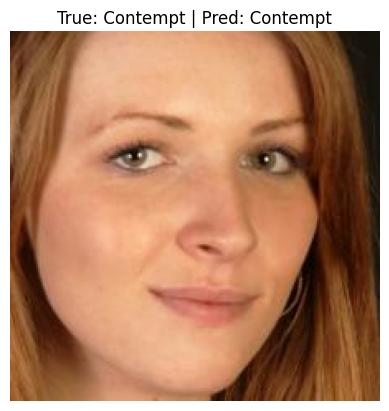

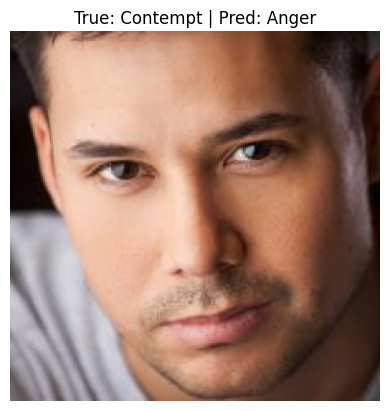

In [ ]:
preds, labels, all_images = evaluate_with_preds_and_images(model, test_loader)
show_example(all_images, labels, preds, correct=True)
show_example(all_images, labels, preds, correct=False)

In [ ]:
torch.save(model.state_dict(), "multitask_efficientnet_b0.pth")

**VGG16**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskCNN("vgg16").to(device)

# Losses + Optimizer
ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Epoch 1/10
  Train Loss: 2.0962 (Cls: 2.0005, Reg: 0.1915)
  Val Loss:   1.8648, Val Acc: 0.3172
Epoch 2/10
  Train Loss: 1.7160 (Cls: 1.6331, Reg: 0.1659)
  Val Loss:   1.6753, Val Acc: 0.3773
Epoch 3/10
  Train Loss: 1.3742 (Cls: 1.2948, Reg: 0.1589)
  Val Loss:   1.6529, Val Acc: 0.4040
Epoch 4/10
  Train Loss: 0.9831 (Cls: 0.9001, Reg: 0.1659)
  Val Loss:   2.0374, Val Acc: 0.3940
Epoch 5/10
  Train Loss: 0.5411 (Cls: 0.4453, Reg: 0.1916)
  Val Loss:   1.9306, Val Acc: 0.4190
Epoch 6/10
  Train Loss: 0.2416 (Cls: 0.1535, Reg: 0.1763)
  Val Loss:   2.2632, Val Acc: 0.4257
Epoch 7/10
  Train Loss: 0.1104 (Cls: 0.0552, Reg: 0.1105)
  Val Loss:   2.1828, Val Acc: 0.4290
Epoch 8/10
  Train Loss: 0.0571 (Cls: 0.0233, Reg: 0.0675)
  Val Loss:   2.2565, Val Acc: 0.4307
Epoch 9/10
  Train Loss: 0.0392 (Cls: 0.0171, Reg: 0.0442)
  Val Loss:   2.2529, Val Acc: 0.4307
Epoch 10/10
  Train Loss: 0.0310 (Cls: 0.0138, Reg: 0.0343)
  Val Loss:   2.2028, Val Acc: 0.4424


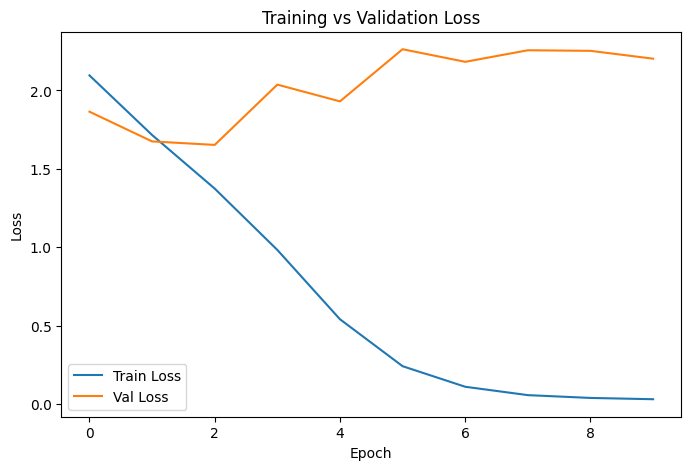

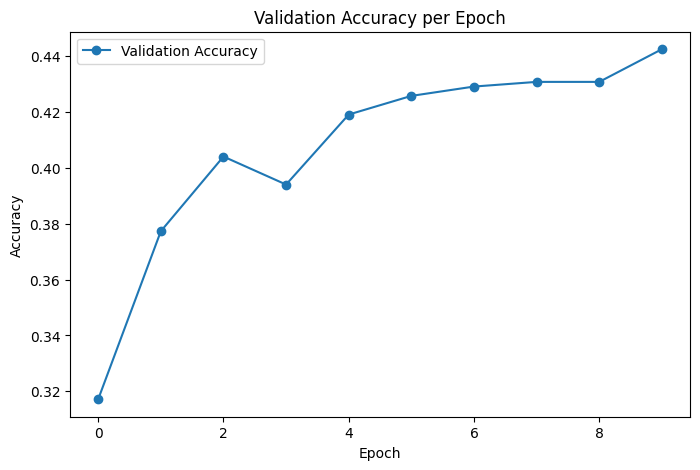

In [ ]:
# Tracking lists
train_losses, train_cls_losses, train_reg_losses = [], [], []
val_losses, val_accs = [], []

num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_cls, train_reg = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)

    # Save history
    train_losses.append(train_loss)
    train_cls_losses.append(train_cls)
    train_reg_losses.append(train_reg)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} (Cls: {train_cls:.4f}, Reg: {train_reg:.4f})")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# ---- Plot Curves ----
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(val_accs, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy per Epoch")
plt.show()

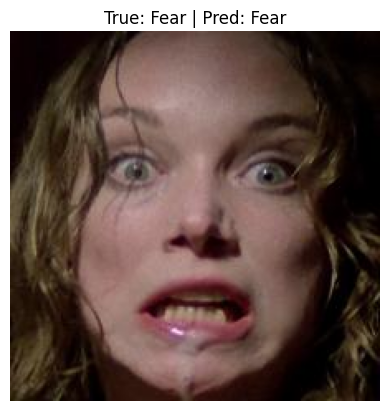

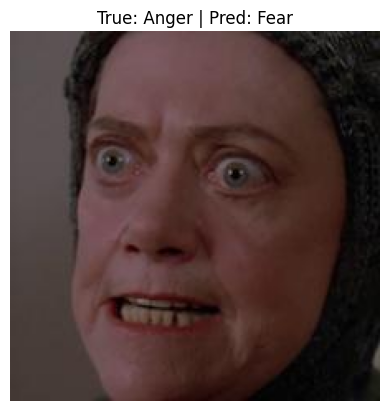

In [ ]:
preds, labels, all_images = evaluate_with_preds_and_images(model, test_loader)
show_example(all_images, labels, preds, correct=True)
show_example(all_images, labels, preds, correct=False)

In [ ]:
torch.save(model.state_dict(), "multitask_vgg16.pth")

**MobileNetV2**

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MultiTaskCNN("mobilenet_v2").to(device)

# Losses + Optimizer
ce_loss = nn.CrossEntropyLoss()
mse_loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 121MB/s]


Epoch 1/10
  Train Loss: 2.0118 (Cls: 1.9034, Reg: 0.2168)
  Val Loss:   1.7271, Val Acc: 0.3823
Epoch 2/10
  Train Loss: 1.4810 (Cls: 1.4126, Reg: 0.1369)
  Val Loss:   1.6462, Val Acc: 0.4057
Epoch 3/10
  Train Loss: 1.0554 (Cls: 1.0011, Reg: 0.1085)
  Val Loss:   1.6489, Val Acc: 0.4290
Epoch 4/10
  Train Loss: 0.6088 (Cls: 0.5683, Reg: 0.0809)
  Val Loss:   1.7763, Val Acc: 0.4357
Epoch 5/10
  Train Loss: 0.2733 (Cls: 0.2444, Reg: 0.0577)
  Val Loss:   1.9151, Val Acc: 0.4307
Epoch 6/10
  Train Loss: 0.1306 (Cls: 0.1062, Reg: 0.0489)
  Val Loss:   2.0232, Val Acc: 0.4391
Epoch 7/10
  Train Loss: 0.0776 (Cls: 0.0565, Reg: 0.0423)
  Val Loss:   2.0604, Val Acc: 0.4407
Epoch 8/10
  Train Loss: 0.0529 (Cls: 0.0343, Reg: 0.0373)
  Val Loss:   2.1557, Val Acc: 0.4574
Epoch 9/10
  Train Loss: 0.0408 (Cls: 0.0232, Reg: 0.0351)
  Val Loss:   2.1691, Val Acc: 0.4524
Epoch 10/10
  Train Loss: 0.0305 (Cls: 0.0154, Reg: 0.0302)
  Val Loss:   2.2230, Val Acc: 0.4357


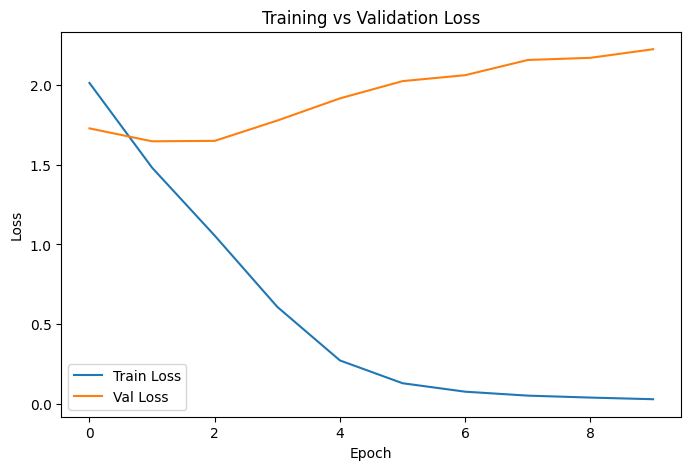

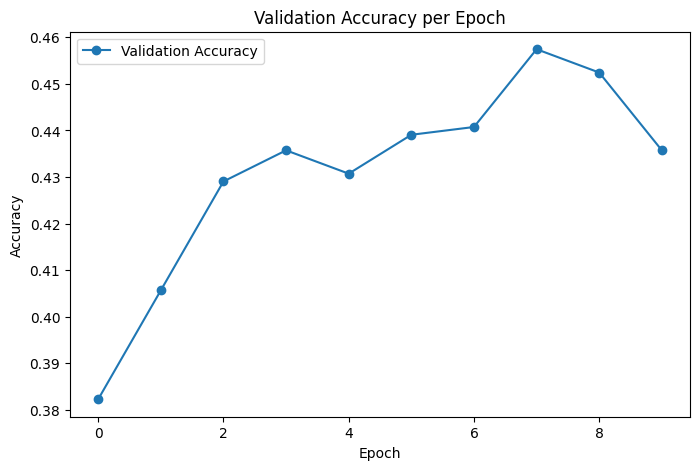

In [ ]:
# Tracking lists
train_losses, train_cls_losses, train_reg_losses = [], [], []
val_losses, val_accs = [], []

num_epochs = 10
for epoch in range(num_epochs):
    train_loss, train_cls, train_reg = train_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = evaluate(model, val_loader)

    # Save history
    train_losses.append(train_loss)
    train_cls_losses.append(train_cls)
    train_reg_losses.append(train_reg)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train Loss: {train_loss:.4f} (Cls: {train_cls:.4f}, Reg: {train_reg:.4f})")
    print(f"  Val Loss:   {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# ---- Plot Curves ----
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

plt.figure(figsize=(8,5))
plt.plot(val_accs, label="Validation Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Validation Accuracy per Epoch")
plt.show()

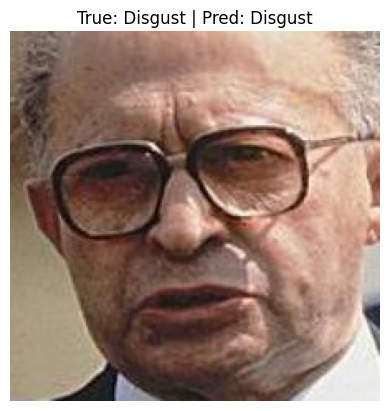

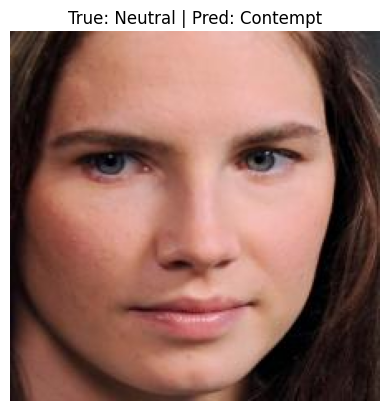

In [ ]:
preds, labels, all_images = evaluate_with_preds_and_images(model, test_loader)
show_example(all_images, labels, preds, correct=True)
show_example(all_images, labels, preds, correct=False)

In [ ]:
torch.save(model.state_dict(), "multitask_mobilenet_v2.pth")

**Testing and Comparison**

In [ ]:
# ResNet18
resnet_model = MultiTaskCNN("resnet18")
resnet_model.load_state_dict(torch.load("multitask_resnet18.pth", map_location=device))
resnet_model.to(device)
resnet_model.eval()

# EfficientNet-B0
effnet_model = MultiTaskCNN("efficientnet_b0")
effnet_model.load_state_dict(torch.load("multitask_efficientnet_b0.pth", map_location=device))
effnet_model.to(device)
effnet_model.eval()

# VGG16
vgg_model = MultiTaskCNN("vgg16")
vgg_model.load_state_dict(torch.load("multitask_vgg16.pth", map_location=device))
vgg_model.to(device)
vgg_model.eval()

# MobileNetV2
mobilenet_model = MultiTaskCNN("mobilenet_v2")
mobilenet_model.load_state_dict(torch.load("multitask_mobilenet_v2.pth", map_location=device))
mobilenet_model.to(device)
mobilenet_model.eval()

MultiTaskCNN(
  (backbone): MobileNetV2(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(16, 96, kernel_size=

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    cohen_kappa_score, roc_auc_score, average_precision_score,
    mean_squared_error
)
from sklearn.preprocessing import label_binarize
from scipy.stats import pearsonr
import random


In [ ]:
def krippendorffs_alpha_nominal(labels, preds):
    labels, preds = np.array(labels), np.array(preds)
    n = len(labels)

    Do = np.sum(labels != preds) / n
    from collections import Counter
    freq = Counter(labels.tolist() + preds.tolist())
    probs = np.array(list(freq.values())) / (2 * n)
    De = 1 - np.sum(probs ** 2)

    if De == 0: return 1.0
    return 1 - (Do / De)

def correlation(y_true, y_pred):
    return pearsonr(y_true, y_pred)[0]

def sagr(y_true, y_pred):
    return np.mean(np.sign(y_true) == np.sign(y_pred))

def concordance_cc(y_true, y_pred):
    true_mean, pred_mean = np.mean(y_true), np.mean(y_pred)
    true_var, pred_var = np.var(y_true), np.var(y_pred)
    cov = np.mean((y_true - true_mean) * (y_pred - pred_mean))
    return (2 * cov) / (true_var + pred_var + (true_mean - pred_mean)**2)


In [ ]:
def evaluate_full(model, loader, device):
    model.eval()
    all_preds, all_labels, all_vals, all_aros, all_va_preds, all_probs = [], [], [], [], [], []

    softmax = nn.Softmax(dim=1)

    with torch.no_grad():
        for images, exp, val, aro in loader:
            images, exp, val, aro = images.to(device), exp.to(device), val.to(device), aro.to(device)
            va_targets = torch.stack([val, aro], dim=1)

            exp_logits, va_preds = model(images)
            probs = softmax(exp_logits)

            _, preds = exp_logits.max(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(exp.cpu().numpy())
            all_vals.extend(val.cpu().numpy())
            all_aros.extend(aro.cpu().numpy())
            all_va_preds.extend(va_preds.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    # ---- Classification Metrics ----
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    kappa = cohen_kappa_score(all_labels, all_preds)
    alpha = krippendorffs_alpha_nominal(all_labels, all_preds)

    labels_bin = label_binarize(all_labels, classes=list(range(8)))
    auc_roc = roc_auc_score(labels_bin, np.array(all_probs), multi_class='ovo', average='macro')
    auc_pr = average_precision_score(labels_bin, np.array(all_probs), average='macro')

    # ---- Regression Metrics ----
    vals_pred = [v[0] for v in all_va_preds]
    aros_pred = [v[1] for v in all_va_preds]

    rmse_val = np.sqrt(mean_squared_error(all_vals, vals_pred))
    rmse_aro = np.sqrt(mean_squared_error(all_aros, aros_pred))

    corr_val = correlation(all_vals, vals_pred)
    corr_aro = correlation(all_aros, aros_pred)

    sagr_val = sagr(all_vals, vals_pred)
    sagr_aro = sagr(all_aros, aros_pred)

    ccc_val = concordance_cc(np.array(all_vals), np.array(vals_pred))
    ccc_aro = concordance_cc(np.array(all_aros), np.array(aros_pred))

    return {
        "Accuracy": acc,
        "F1": f1,
        "Kappa": kappa,
        "Alpha": alpha,
        "AUC-ROC": auc_roc,
        "AUC-PR": auc_pr,
        "Valence RMSE": rmse_val,
        "Arousal RMSE": rmse_aro,
        "Valence CORR": corr_val,
        "Arousal CORR": corr_aro,
        "Valence SAGR": sagr_val,
        "Arousal SAGR": sagr_aro,
        "Valence CCC": ccc_val,
        "Arousal CCC": ccc_aro,
    }


In [ ]:
df_results = pd.DataFrame([
    evaluate_full(resnet_model, test_loader, device),
    evaluate_full(effnet_model, test_loader, device),
    evaluate_full(vgg_model, test_loader, device),
    evaluate_full(mobilenet_model, test_loader, device)
], index=["ResNet18", "EfficientNet-B0", "VGG16", "MobileNetV2"])


In [ ]:
print(df_results)

                 Accuracy        F1     Kappa     Alpha   AUC-ROC    AUC-PR  \
ResNet18         0.417637  0.419476  0.333452  0.333386  0.806371  0.438948   
EfficientNet-B0  0.424293  0.422405  0.341370  0.340076  0.804943  0.431068   
VGG16            0.447587  0.448197  0.368272  0.367540  0.832325  0.465979   
MobileNetV2      0.415973  0.414332  0.331935  0.331429  0.807519  0.434009   

                 Valence RMSE  Arousal RMSE  Valence CORR  Arousal CORR  \
ResNet18             0.402585      0.376362      0.530636      0.319595   
EfficientNet-B0      0.416103      0.377832      0.533220      0.340469   
VGG16                0.455142      0.408487      0.488844      0.288875   
MobileNetV2          0.393526      0.365508      0.560094      0.371820   

                 Valence SAGR  Arousal SAGR  Valence CCC  Arousal CCC  
ResNet18             0.720466      0.718802     0.484260     0.282546  
EfficientNet-B0      0.688852      0.725458     0.511595     0.312862  
VGG16       

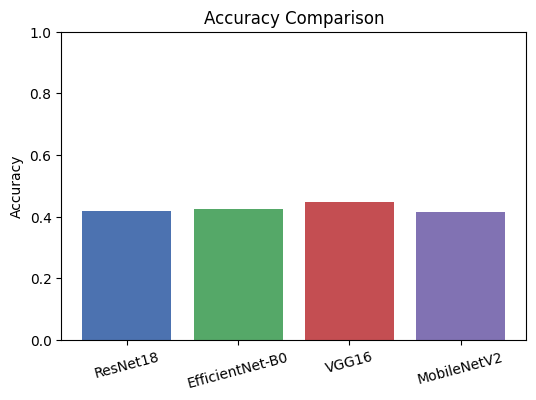

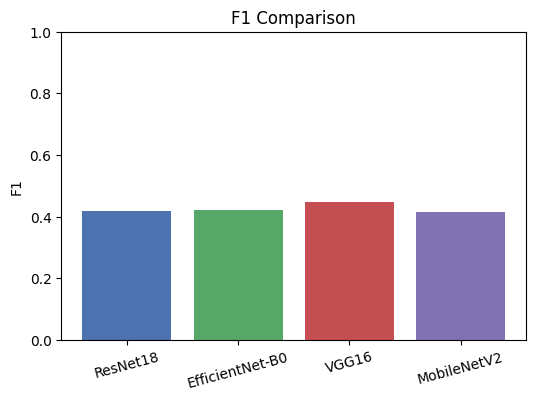

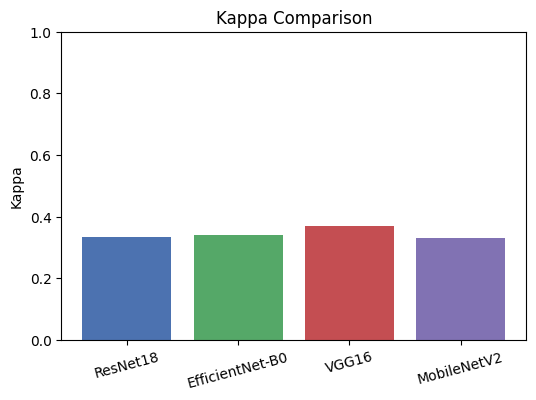

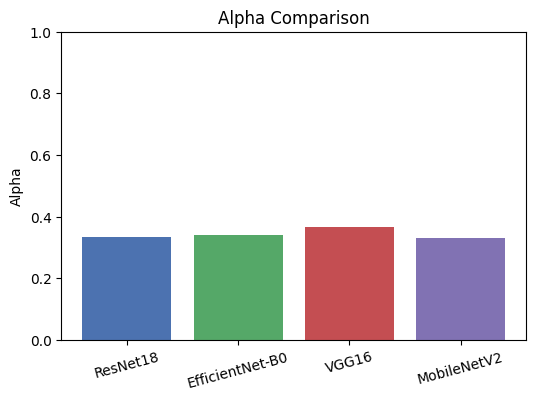

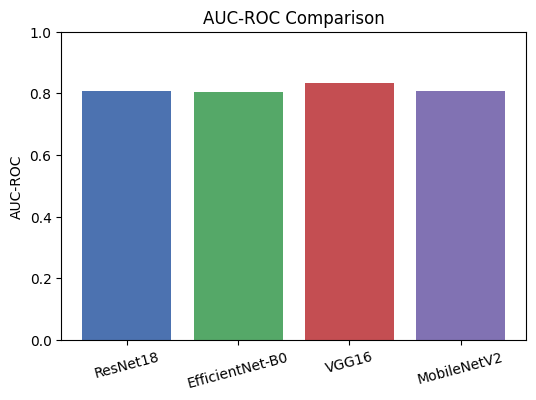

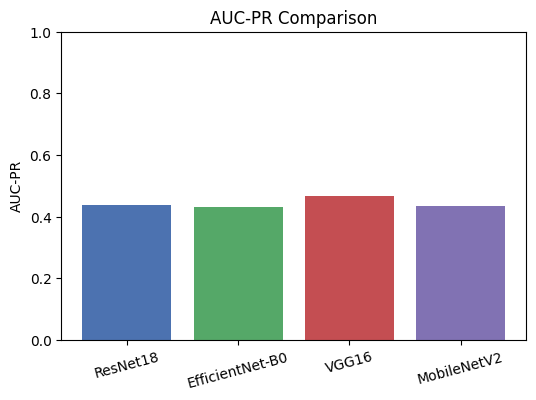

In [ ]:
classification_metrics = ["Accuracy", "F1", "Kappa", "Alpha", "AUC-ROC", "AUC-PR"]

for metric in classification_metrics:
    plt.figure(figsize=(6,4))
    plt.bar(df_results.index, df_results[metric], color=["#4c72b0","#55a868","#c44e52","#8172b3"])
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.ylim(0, 1)  # since most classification metrics are in [0,1]
    plt.show()


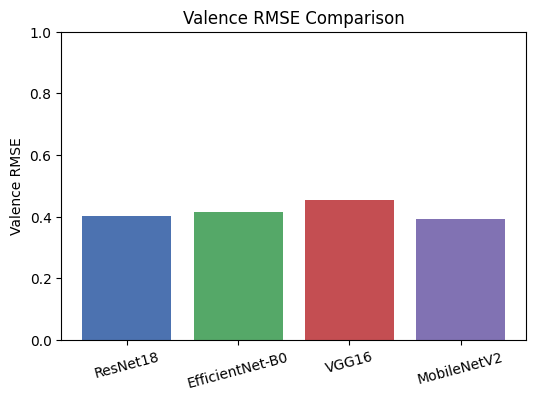

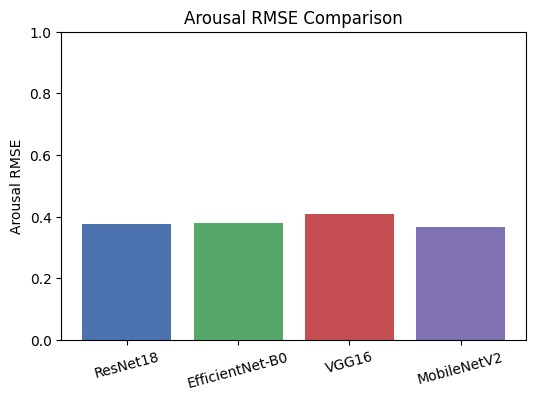

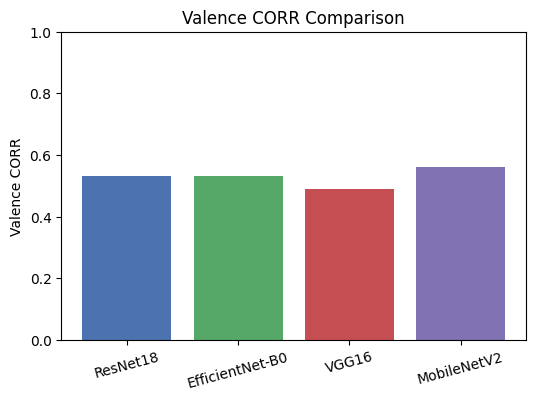

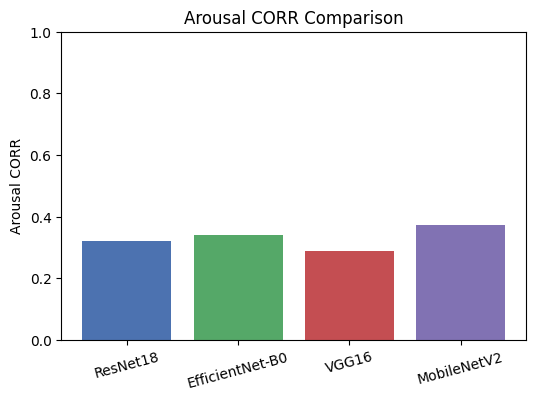

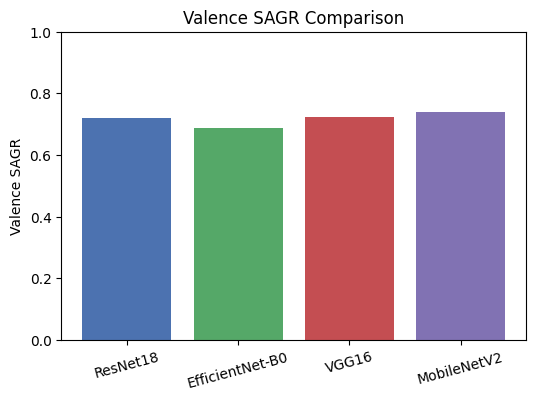

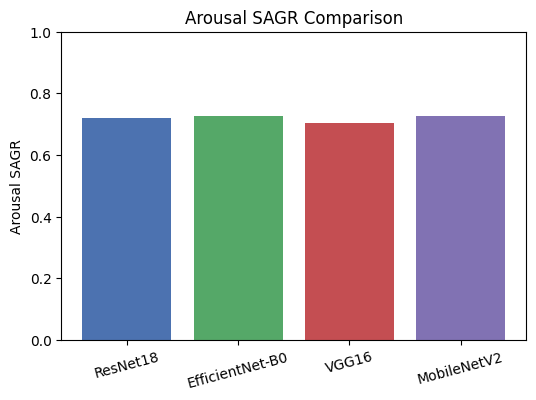

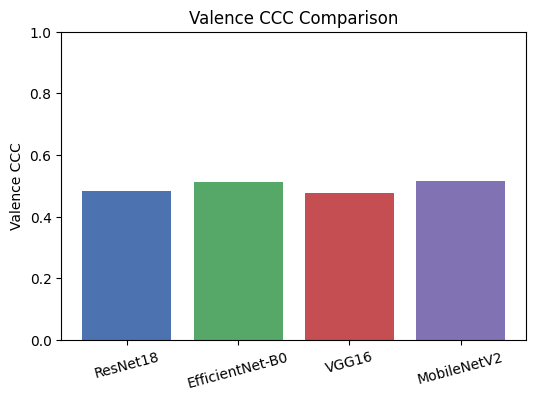

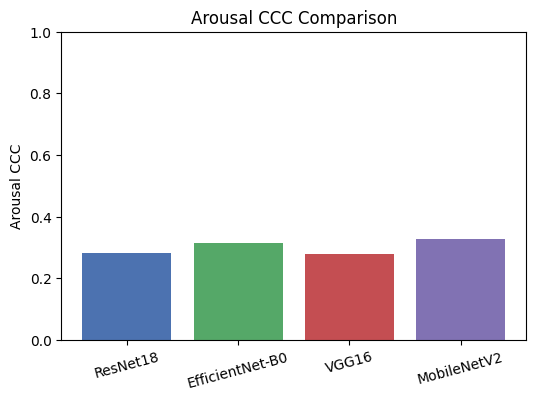

In [ ]:
regression_metrics = ["Valence RMSE", "Arousal RMSE",
                      "Valence CORR", "Arousal CORR",
                      "Valence SAGR", "Arousal SAGR",
                      "Valence CCC", "Arousal CCC"]

for metric in regression_metrics:
    plt.figure(figsize=(6,4))
    plt.bar(df_results.index, df_results[metric], color=["#4c72b0","#55a868","#c44e52","#8172b3"])
    plt.title(f"{metric} Comparison")
    plt.ylabel(metric)
    plt.xticks(rotation=15)

    # Better visuals: RMSE is "lower is better", so auto-scale differently
    if "RMSE" in metric:
        plt.ylim(0, 1)
    else:
        plt.ylim(0, 1)

    plt.show()


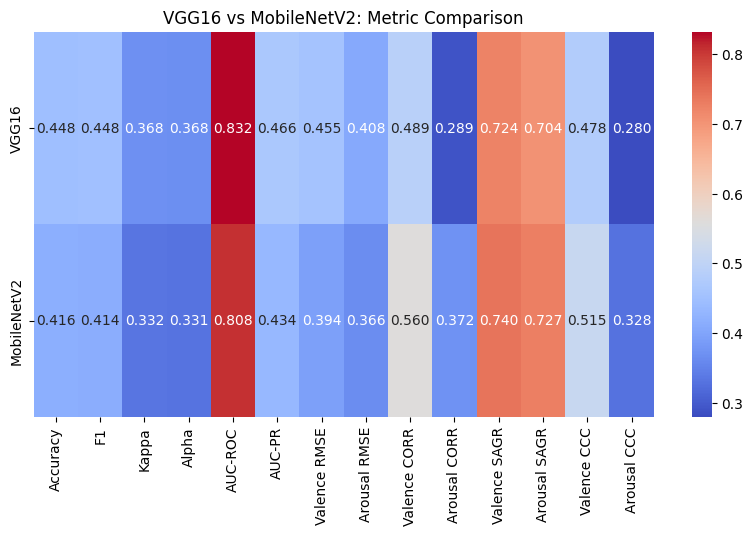

In [ ]:
import seaborn as sns

subset_df = df_results.loc[["VGG16", "MobileNetV2"]]

plt.figure(figsize=(10,5))
sns.heatmap(subset_df, annot=True, fmt=".3f", cmap="coolwarm", cbar=True)
plt.title("VGG16 vs MobileNetV2: Metric Comparison")
plt.show()
